## PHYS-467 Machine Learning for Physicists. Exercise session 3

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import sklearn.linear_model as linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import sklearn.preprocessing as preprocessing

# Exercise 1: Linear Regression in 1D

**Question 1.a)** Write a function that creates one dimensional linear data and add a gaussian noise i.e $y = a \times x + \varepsilon$

In [22]:
def generate_data(n_data, coefficient, variance):
    X = np.random.normal(size=(n_data,))
    y = X * coefficient + np.sqrt(variance) * np.random.normal(size=(n_data,))

    return X.reshape((-1, 1)), y

In [23]:
coefficient = 3
n_data      = 10
X, y = generate_data(n_data, coefficient, 0.5)
X.shape

(10, 1)

**Question 1.b)** Generate and plot some data (X, Y), along with the noiseless function $y = a \times x$

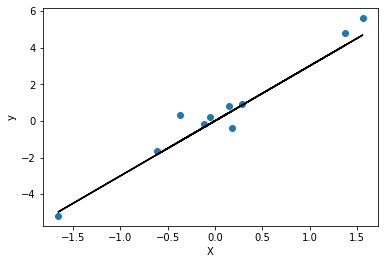

In [24]:
# Plot the training data

plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y');

# ground truth 
plt.plot(X, coefficient * X, c='k')

**Question 2** Write a function to compute the least-square regression using the closed form seen in class.
Use this function on the  training data generated previously.

In [25]:
# Write a function to compute the linear-regression predictor in close form

def linear_regression(X, y):
    """
    arguments:
        - X : data matrix
        - y : output
    returns:
        - w : the least square estimator
    """
    lambda_ = 1.0
    X = np.concatenate((X, np.ones((len(X), 1))), axis=1) # Add column for bias
    w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return w

In [26]:
# Print the predicted weights (coefficient + bias)

w = linear_regression(X, y)
w

array([3.21724014, 0.29861318])

**Question 3** Generate a grid of points and apply your predictor on this grid. Plot it along your training set.

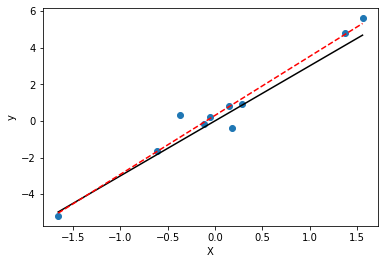

In [27]:
# Plot the training points and the predictor evaluated on a set of test points

X_test = np.linspace(np.min(X), np.max(X), 10)
y_test_pred = w[0] * X_test + w[1]

plt.scatter(X, y)
plt.plot(X_test, coefficient * X_test, 'k')
plt.plot(X_test, y_test_pred, 'r--')
plt.xlabel('X')
plt.ylabel('y');

**Question 4** Repeat the same with `LinearRegression` of the module [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). Check that the coefficients are the same.

In [28]:
# Repeat with Scikit-learn

linear_regression_sk = LinearRegression()
linear_regression_sk.fit(X, y)
print('sklearn : ', linear_regression_sk.coef_, linear_regression_sk.intercept_)
print('w : ', w)

sklearn :  [3.21724014] 0.2986131766126353
w :  [3.21724014 0.29861318]


# Exercise 2: Spectrum of covariance in high dimensions

**Question 1** Consider $X$ a $n \times d$ Gaussian matrix. Compute and plot the spectrum of the covariance matrix $X^T X$ for dimension d = 50 and varying $n$. Look at the evolution of its rank as a function of $\alpha = n/d$. What happens at $\alpha = 1$ ?


In [29]:
def generate_covariance_matrix(n, d):
    """
    arguments: 
        - n : number of samples
        - d : dimension
    returns:
        - covariance matrix of n x d matrix X
    """
    X = np.random.normal(size=(n, d))
    return X.T @ X / n

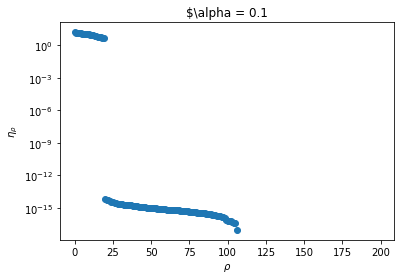

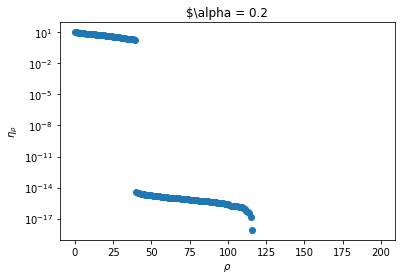

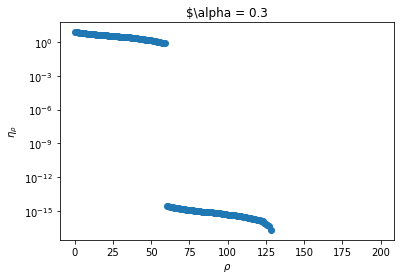

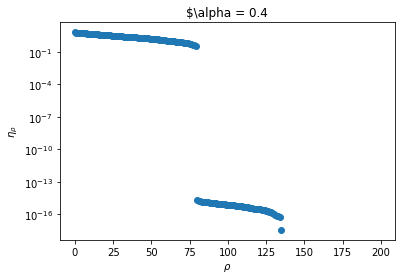

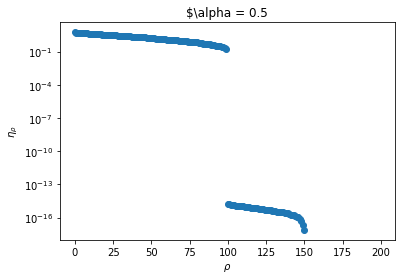

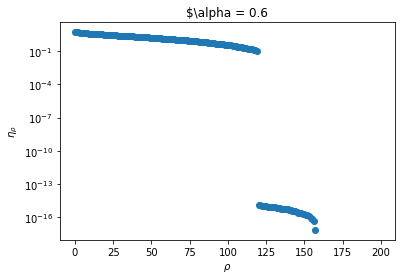

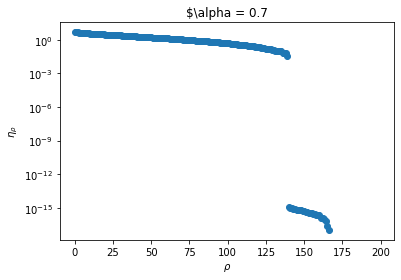

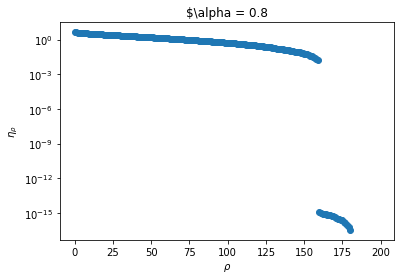

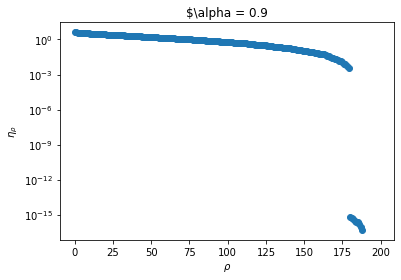

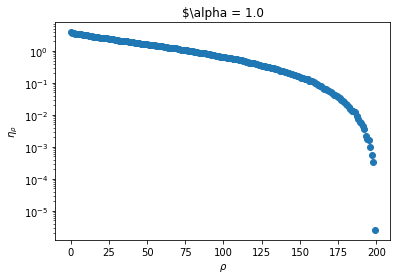

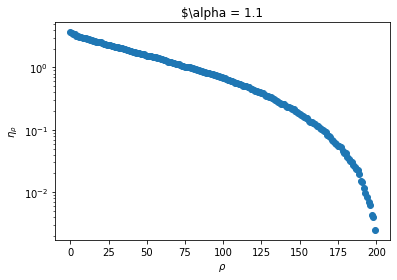

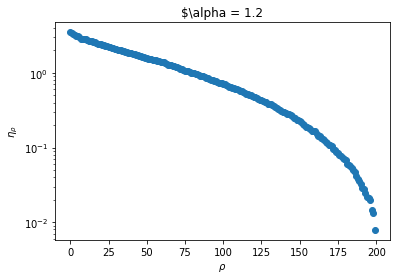

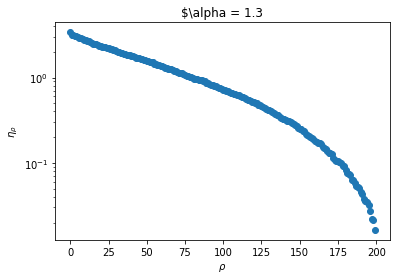

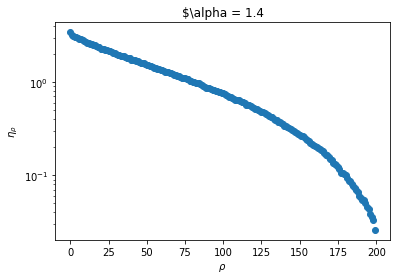

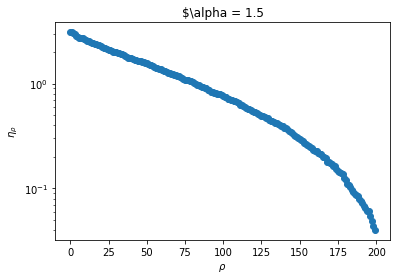

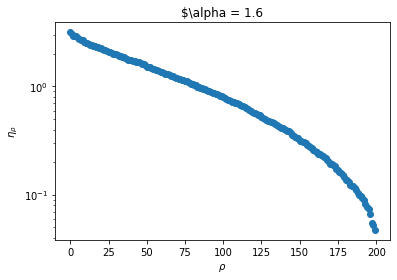

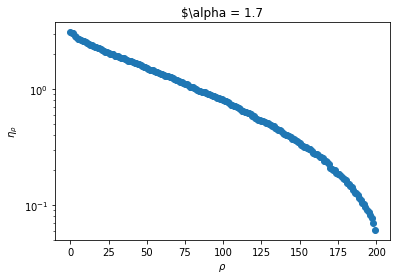

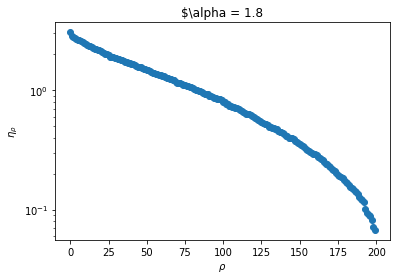

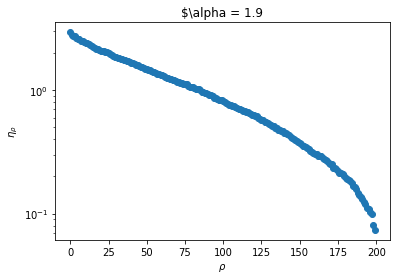

In [30]:
# Compute the rank and plot the eigenvalues of the matrix X.T X varying alpha = n / d

d = 200
n_list = np.arange(int(0.1 * d), int(2 * d), 20)

rank_list = []

for n in n_list:

    cov = generate_covariance_matrix(n, d)
    rank = np.linalg.matrix_rank(cov)
    rank_list.append(rank)
    evals = np.linalg.eigh(cov)[0]
    evals = np.sort(evals)[::-1]

    plt.semilogy(evals, 'o')
    plt.xlabel(r'$\rho$')
    plt.ylabel(r'$\eta_{\rho}$')
    plt.title(f'$\\alpha = {n / d}')

    plt.show()

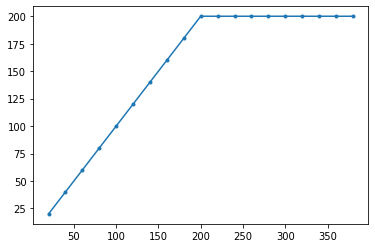

In [31]:
plt.plot(n_list, rank_list, marker='.')
plt.show()

**Question 2** Add a regularisation term $\lambda$. What happens to the spectrum ?

n = 20, d = 200, alpha = 0.1, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


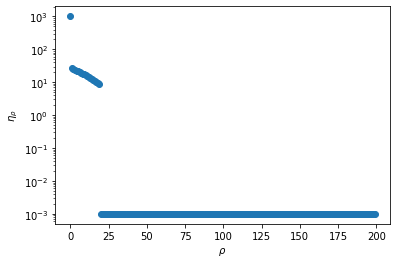

n = 40, d = 200, alpha = 0.2, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


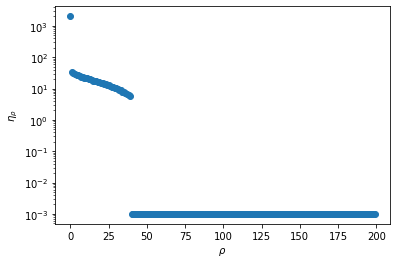

n = 60, d = 200, alpha = 0.3, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


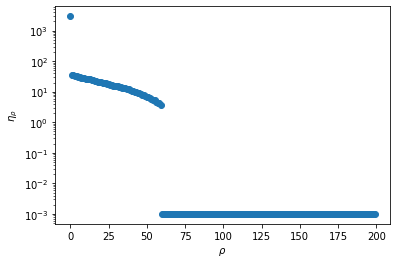

n = 80, d = 200, alpha = 0.4, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


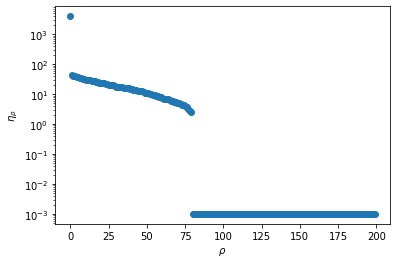

n = 100, d = 200, alpha = 0.5, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


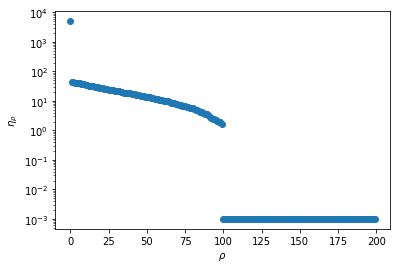

n = 120, d = 200, alpha = 0.6, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


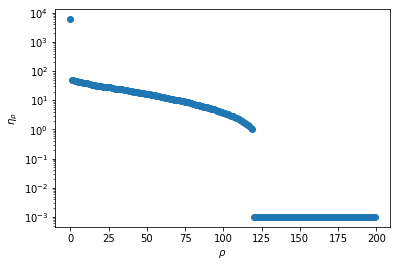

n = 140, d = 200, alpha = 0.7, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


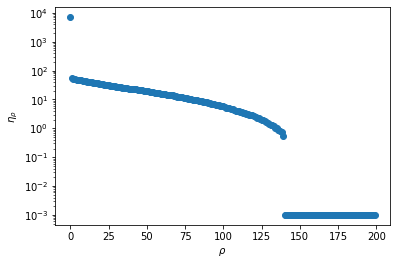

n = 160, d = 200, alpha = 0.8, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


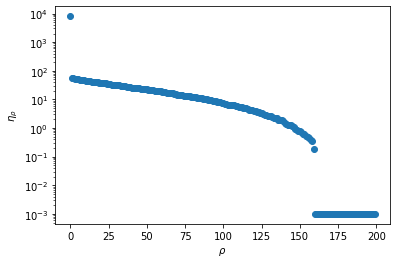

n = 180, d = 200, alpha = 0.9, rank(X.T X) = 200


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


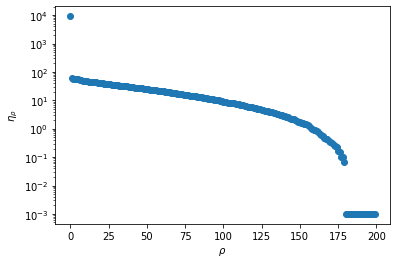

n = 200, d = 200, alpha = 1.0, rank(X.T X) = 200


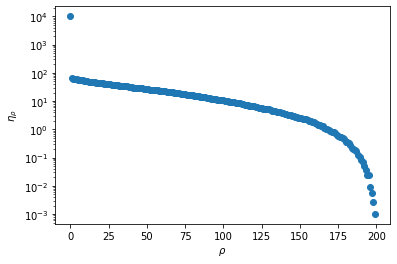

n = 220, d = 200, alpha = 1.1, rank(X.T X) = 200


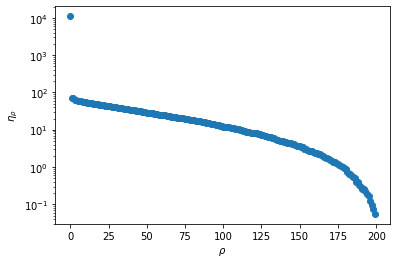

n = 240, d = 200, alpha = 1.2, rank(X.T X) = 200


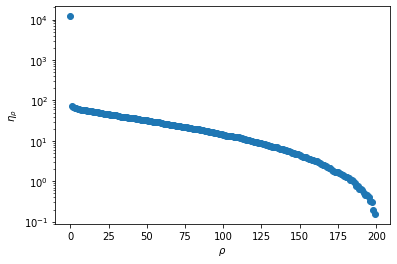

n = 260, d = 200, alpha = 1.3, rank(X.T X) = 200


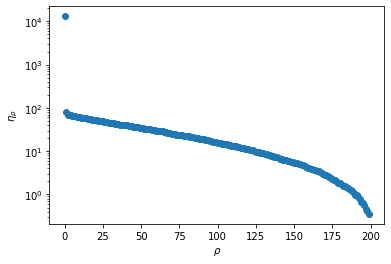

n = 280, d = 200, alpha = 1.4, rank(X.T X) = 200


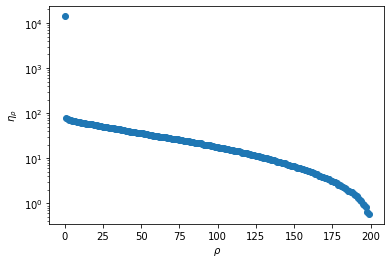

n = 300, d = 200, alpha = 1.5, rank(X.T X) = 200


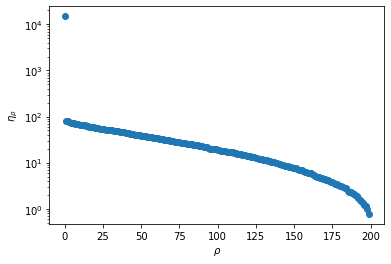

n = 320, d = 200, alpha = 1.6, rank(X.T X) = 200


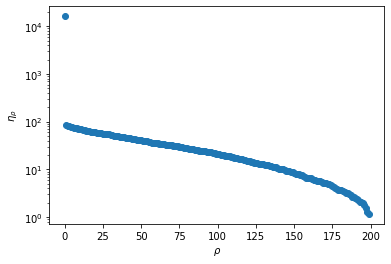

n = 340, d = 200, alpha = 1.7, rank(X.T X) = 200


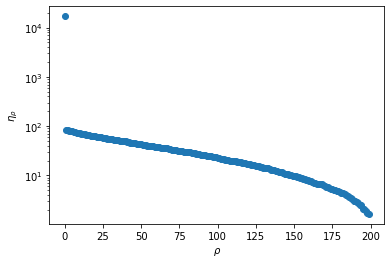

n = 360, d = 200, alpha = 1.8, rank(X.T X) = 200


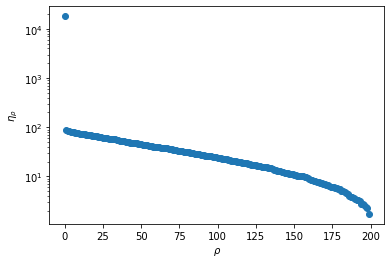

n = 380, d = 200, alpha = 1.9, rank(X.T X) = 200


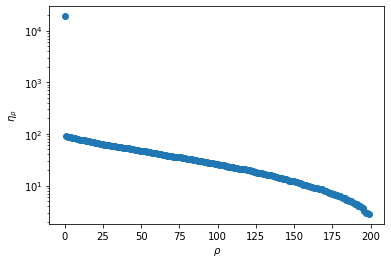

In [32]:
# Add a regularisation. What happens to the spectrum?

reg = 0.001

min_eigenvalue_list = []

for n in n_list:

    X = np.random.rand(n, d)
    rank = np.linalg.matrix_rank(X.T.dot(X) + reg * np.eye(d))
    evals = np.linalg.eigvals(X.T.dot(X) + reg * np.eye(d))
    evals = np.sort(evals)[::-1]
    min_eigenvalue_list.append(np.min(evals))

    print(f'n = {n}, d = {d}, alpha = {n / d}, rank(X.T X) = {rank}')
    plt.semilogy(evals, 'o')
    plt.xlabel(r'$\rho$')
    plt.ylabel(r'$\eta_{\rho}$')
    plt.show();

/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


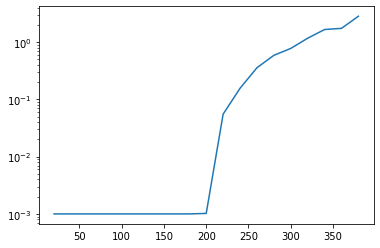

In [33]:
plt.semilogy(n_list, min_eigenvalue_list)

**Question 3** Plot the behaviour of the test error vs alpha for noiseless high-dimensional linear data in the absence of noise. You can use $d = 100$ and $10 \leqslant n \leqslant 500$. What do you observe at $\alpha = 1$

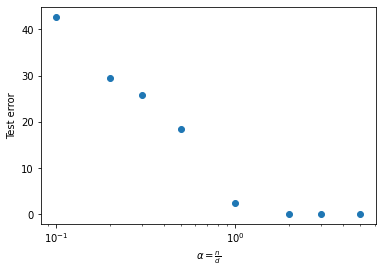

In [34]:
from sklearn.metrics import mean_squared_error

d = 100

train_set_sizes = np.array([500, 300, 200, 100, 50, 30, 20, 10])

X = np.random.rand(np.max(train_set_sizes) + 500, d)
w = 2 * np.random.randn(d, 1)
y = X.dot(w) + 2

mse = []
for n in train_set_sizes:
    X_train = X[:n]
    y_train = y[:n]
    linear_regression_sk.fit(X_train, y_train) # Fits the training data
    X_test = X[-500:]
    y_test = y[-500:]
    y_test_pred = linear_regression_sk.predict(X_test) # Predicts the labels of the test points
    mse.append(mean_squared_error(y_test, y_test_pred)) # Computes the mean squared error

plt.semilogx(train_set_sizes / d, mse, 'o')
plt.xlabel(r'$\alpha=\frac{n}{d}$')
plt.ylabel('Test error');

# Exercise 3: Polynomial Regression, Underfitting & Overfitting

**Question 1** Generate _noiseless_ points $x_1, ... x_n$ with few samples (say $5 \leqslant n \leqslant 10$) and $y_i = x_i^2$. Using [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) from sklearn, fit polynomials of varying degrees $d$ on your training data.

a) Plot the different polynomials obtained. What do you observe ? 

b) As a function of $d$, plot the squared $\ell_2$ norm of the predictors (i.e the sum of the squared coefficients). Compare with the norm of the true function $y_i = x_i^2$. 

In [35]:
def generate_data(polynome, bruit_std, n):
    """
    arguments:
        - polynome  : list of coefficients representing the polynom (polynome[i] multiplies X^i)
        - bruit_std : standard deviation of the gaussian noise
        - n         : number of data points
    returns: 
        - (X, y)    : list of n points with y = P(x) + gaussian noise
    """    
    degree  = len(polynome) - 1
    samples = np.random.uniform(-2, 2, size=n)
    xs      = np.copy(samples)
    samples = np.ones((n, degree + 1)).T * samples
    powers  = np.power(samples.T, np.arange(0, degree + 1, 1))
    return xs, np.sum(powers * polynome, axis = 1) + np.random.normal(0, bruit_std, size=n)

In [36]:
n       = 5
bound   = 3
# function y = x^2
polynom = np.array( [0, 0, 1] )

xs, ys   = generate_data(polynom, 0.0, n)

Degree 1 : training error is 2.254494166546413
Degree 3 : training error is 1.312107182161858e-30
Degree 5 : training error is 7.83068194245606e-27
Degree 7 : training error is 2.001579595341677e-26
Degree 9 : training error is 1.7522740499793734e-26


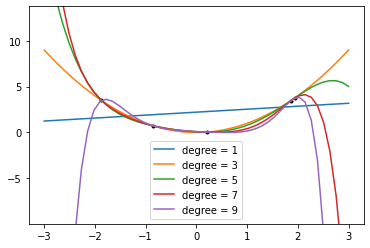

In [37]:
# Fit the data

x_grid = np.linspace(-bound, bound, 50)

degrees = np.arange(1, 10, 2)
coefs = []


for d in degrees:
    poly     = preprocessing.PolynomialFeatures(d)
    xs_trans = poly.fit_transform(xs.reshape(-1, 1))
    x_grid_trans = poly.fit_transform(x_grid.reshape((-1, 1)))
    lr = linear_model.Ridge(alpha = 0.0, fit_intercept=False).fit(xs_trans, ys)
    y_pred = xs_trans @ lr.coef_
    coefs.append(lr.coef_)
    plt.plot(x_grid, x_grid_trans @ lr.coef_, label=f'degree = {d}')
    print(f'Degree {d} : training error is {mean_squared_error(ys, y_pred)}')

plt.scatter(xs, ys, marker='.', c='k')
plt.ylim(np.min(ys) - 10, np.max(ys) + 10)
plt.legend()

L2 norm of the coefficients :  [5.023989246458927, 0.9999999999999996, 0.7001747547015044, 0.32630688793966256, 0.21474531628912402]


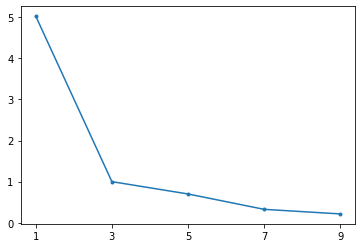

In [38]:
print('L2 norm of the coefficients : ', [np.linalg.norm(c)**2 for c in coefs])

plt.plot(degrees, [np.linalg.norm(c)**2 for c in coefs], marker='.')
plt.xticks(degrees)
plt.show()

**Question 2** Now, generate _noisy_ quadratic data (i.e $y = x^2 + \varepsilon$) and fit again polynoms of various degrees. Sample a large test set and plot the test error as a function of the degree $d$ of the predictor. Observe the under/overfitting phenomenon.

Add a $\ell_2$ regularisation term for the high-degree polynomial case. What happens ? Try to vary the strenth of the regularization.

Degree 1 : MSE is 15.236619765840107
Degree 2 : MSE is 2.118881808712297
Degree 4 : MSE is 267.2296976704245
Degree 8 : MSE is 277034743087.1833


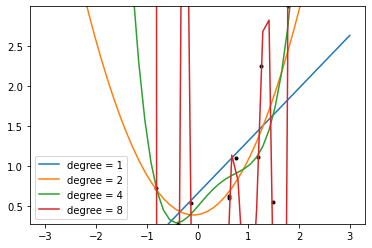

In [39]:
xs, ys  = generate_data(polynom, 0.5, 10)
y_true  = x_grid**2

degrees = np.array([1, 2, 4, 8])

plt.scatter(xs, ys, c='k', marker='.')

for d in degrees:
    poly     = preprocessing.PolynomialFeatures(d)
    xs_trans = poly.fit_transform(xs.reshape(-1, 1))
    x_grid_trans = poly.fit_transform(x_grid.reshape((-1, 1)))
    lr = linear_model.Ridge(alpha = 0.0, fit_intercept=False).fit(xs_trans, ys)
    y_pred = x_grid_trans @ lr.coef_
    plt.plot(x_grid, y_pred, label=f'degree = {d}')
    print(f'Degree {d} : MSE is {mean_squared_error(y_true, y_pred)}')

plt.legend()
plt.ylim(min(ys), max(ys))
plt.show()

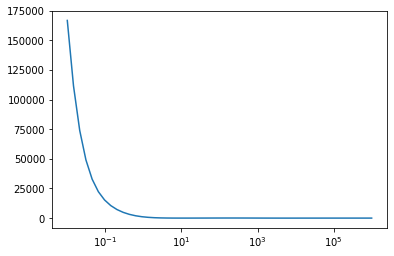

In [40]:
lambda_range = np.logspace(-2, 6, 50)
d = 6
ridge_mses = []

poly     = preprocessing.PolynomialFeatures(d)
xs_trans = poly.fit_transform(xs.reshape(-1, 1))
x_grid_trans = poly.fit_transform(x_grid.reshape((-1, 1)))
y_true = x_grid**2

for lambda_ in lambda_range:
    lr = linear_model.Ridge(alpha = lambda_, fit_intercept=False).fit(xs_trans, ys)
    y_pred = x_grid_trans @ lr.coef_
    ridge_mses.append(mean_squared_error(y_true, y_pred))

plt.semilogx(lambda_range, ridge_mses)


**Bonus question** Let's replace the $\ell_2$ penalty by a $\ell_1$ : 

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.628e-01, tolerance: 1.841e-03
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.579e-02, tolerance: 1.841e-03
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisa

[0.         0.         0.         0.         0.         0.
 0.02326041]
5.7627501117589555 4.005928683215864


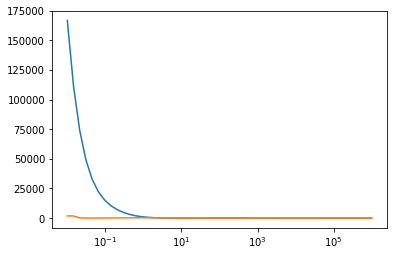

In [41]:
lasso_mses = []

poly     = preprocessing.PolynomialFeatures(d)
xs_trans = poly.fit_transform(xs.reshape(-1, 1))
x_grid_trans = poly.fit_transform(x_grid.reshape((-1, 1)))
y_true = x_grid**2

for lambda_ in lambda_range:
    lr = linear_model.Lasso(alpha = lambda_, fit_intercept=False).fit(xs_trans, ys)
    y_pred = x_grid_trans @ lr.coef_
    lasso_mses.append(mean_squared_error(y_true, y_pred))

plt.semilogx(lambda_range, ridge_mses)
plt.semilogx(lambda_range, lasso_mses)

optimal_lambda_l1 = lambda_range[np.argmin(lasso_mses)]
lr = linear_model.Lasso(alpha = optimal_lambda_l1, fit_intercept=False).fit(xs_trans, ys)
print(lr.coef_)

print(np.min(lasso_mses), np.min(ridge_mses))



# Exercise 4: Real Data

**Question 1** Load the housing house prices dataset. Split the dataset into a training and test set, using for example a 80% / 20% split. 

* To load the data : https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_housing.html
* To split the data : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [42]:
# Load the housing prices dataset (goal: predict the price of a house from 8 different features)

housing = fetch_california_housing()
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [43]:
housing.data.shape

(20640, 8)

In [44]:
# Split data in training and testing set

X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, test_size=0.2)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.25)

**Question 2** Fit a linear model on the training set, and compute the predictions $\hat y$ of your model. Compare them to the true values $y^*$, for example by printing the mean squared error.

In [45]:
# Perform linear regression on the training set

linear_regression_sk = LinearRegression()
linear_regression_sk.fit(X_train, y_train);

mse: 0.525126506146716


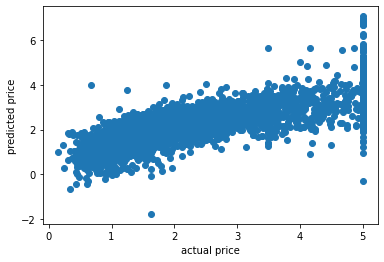

In [46]:
# Print the test error and plot the predicted prices vs the actual ones

y_pred = linear_regression_sk.predict(X_test)
print(f'mse: {mean_squared_error(y_test, y_pred)}')

plt.scatter(y_test, y_pred)
plt.xlabel('actual price')
plt.ylabel('predicted price');

**Question 3** Redo the question 2 while varying the size of the training set. For each size, compute the training and test error. How do they vary as a function of the training size ? 

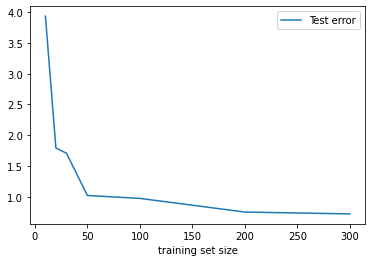

In [51]:
# Vary the training set size n and plot the learning curves (test and train error vs n)
# Comments: the train error is growing while the test error is going down, test error > train error, the curves are converging

trainset_sizes = [10, 20, 30, 50, 100, 200, 300]

train_errors = []
test_errors = []

for n in trainset_sizes:

    linear_regression_sk.fit(X_train[:n], y_train[:n])

    y_train_pred = linear_regression_sk.predict(X_train[:n])
    train_errors.append(mean_squared_error(y_train[:n], y_train_pred))

    y_test_pred = linear_regression_sk.predict(X_test)
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# plt.plot(trainset_sizes, train_errors, label='Train error')
plt.plot(trainset_sizes, test_errors, label='Test error')
plt.xlabel('training set size')
plt.legend();

**Question 4** First, implement a function that generates _non-interactive_ polynomial features : for a degree $k$ and an input $x = x_1, ..., x_d$, generate $\tilde x = x_1, ..., x_1^k, x_2, ..., x_2^k, ... x_d^k$.
Then, run a linear regression on these polynomial features with different degrees $k$. 
Observe the under/overfitting phenomenon.

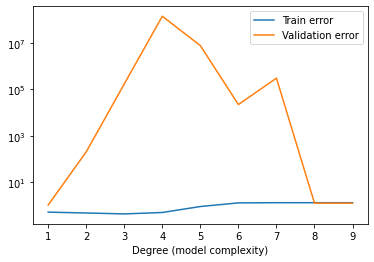

In [48]:
# Implement *non-interacting* polynomial-features regression (not present in sklearn, write a function using numpy) and vary the degree from 1 to 6. Plot the results.
# Comments: bias-variance tradeoff, U-shaped curve (while train error keeps going down, i.e. overfitting)

def non_interacting_polyfeat(X, k):
    """
    arguments: 
        - X : n x d matrix, where each row is a data sample
        - k : degree of the desired polynomial features
    returns: 
        - X2 : n x (dk) matrix containing the polynomial features
    """
    return np.concatenate([X**(i+1) for i in range(k)], axis=1)

train_errors = []
val_errors = []

ndegs = 10
for degree in range(1, ndegs):

    X_train_poly = non_interacting_polyfeat(X_train, degree)
    linear_regression_sk.fit(X_train_poly, y_train)

    y_train_pred_poly = linear_regression_sk.predict(X_train_poly)
    train_errors.append(mean_squared_error(y_train, y_train_pred_poly))

    y_val_pred_poly = linear_regression_sk.predict(non_interacting_polyfeat(X_validation, degree))
    val_errors.append(mean_squared_error(y_validation, y_val_pred_poly))

plt.semilogy(np.arange(1,ndegs), train_errors, label='Train error')
plt.semilogy(np.arange(1,ndegs), val_errors, label='Validation error')
plt.xlabel('Degree (model complexity)')
plt.legend();

**Question 5** From the previous question, pick a degree that you think is best, and add different regularisation strength $\lambda$ to the regression. Plot the training and test errors as a function of $\lambda$.

Best degree is  1


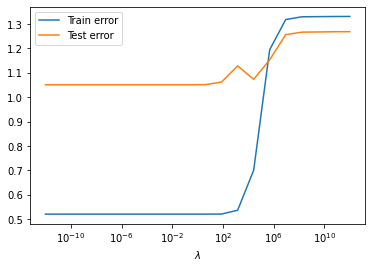

In [49]:
# Add different regularisers to the degree-6 model. Plot the results and find the best value.

best_degree = list(range(1, ndegs))[np.argmin(val_errors)]
print('Best degree is ', best_degree)

reg_strenghts = np.logspace(-12, 12, 20)

train_errors = []
val_errors_lambda = []

for reg_strenght in reg_strenghts:

    X_train_poly = non_interacting_polyfeat(X_train, k=best_degree)

    ridge_regression = Ridge(alpha=reg_strenght)
    ridge_regression.fit(X_train_poly, y_train)

    y_train_pred_poly = ridge_regression.predict(X_train_poly)
    train_errors.append(mean_squared_error(y_train, y_train_pred_poly))

    y_val_pred_poly = ridge_regression.predict(non_interacting_polyfeat(X_validation, k=best_degree))
    val_errors_lambda.append(mean_squared_error(y_validation, y_val_pred_poly))

plt.semilogx(reg_strenghts, train_errors, label='Train error')
plt.semilogx(reg_strenghts, val_errors_lambda, label='Test error')
plt.xlabel('$\lambda$')
plt.legend();

In [50]:
lambda_opt = reg_strenghts[np.argmin(val_errors_lambda)]
print(f'Optimal lambda is {lambda_opt}, the validation error is {np.min(val_errors_lambda)}')

ridge_regression = Ridge(alpha=lambda_opt)
ridge_regression.fit(X_train_poly, y_train)

y_test_pred_poly = ridge_regression.predict(non_interacting_polyfeat(X_test, k=best_degree))
test_error = mean_squared_error(y_test, y_test_pred_poly)
print(f'Test error is {test_error}')

Optimal lambda is 1e-12, the validation error is 1.050425600050684
Test error is 0.5251265061467162
